In [1]:
import pandas as pd
import numpy as np
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection


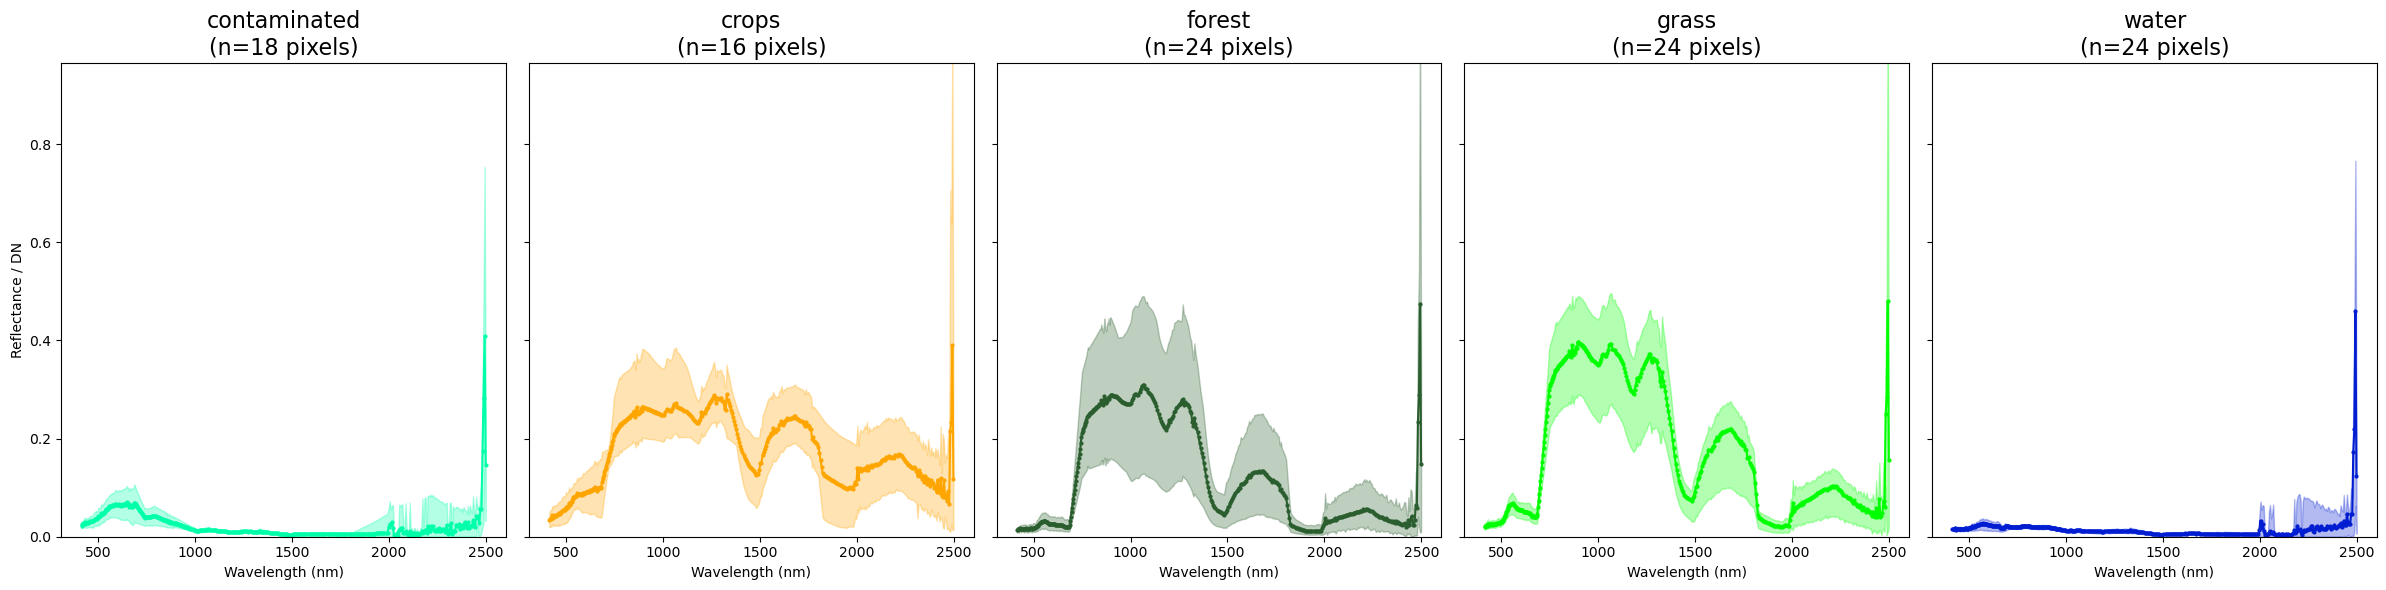

In [2]:
data = pd.read_csv("./exports/spectral_library_master.csv")

spectras = ['contaminated', 'crops', 'forest', 'grass', 'water']
colors_dict = {
    'contaminated': '#00ffaa', 
    'crops': '#FFA500', 
    'forest': '#2A5E2E', 
    'grass': '#00ff00', 
    'water': '#001DD1'
}

fig, axes = plt.subplots(1, len(spectras), figsize=(24, 6), sharey=True)

for i, spectrum in enumerate(spectras):
    ax = axes[i]
    
    subset = data[data['class'] == spectrum]
    
    if subset.empty:
        continue

    stats = subset.groupby('wavelength_nm')['value'].agg(
        mean='mean',
        q5=lambda x: np.percentile(x, 5),
        q95=lambda x: np.percentile(x, 95)
    ).sort_index()
    
    w_vals = stats.index.values
    mean_vals = stats['mean'].values
    q5_vals = stats['q5'].values
    q95_vals = stats['q95'].values
    
    poly_x = np.concatenate([w_vals, w_vals[::-1]])
    poly_y = np.concatenate([q5_vals, q95_vals[::-1]])
    
    polygon = Polygon(np.vstack([poly_x, poly_y]).T)
    p = PatchCollection([polygon], color=colors_dict[spectrum], alpha=0.3)
    ax.add_collection(p)
    
    ax.plot(w_vals, mean_vals, 'o-', markersize=2, color=colors_dict[spectrum])
    
    ax.set_title(f"{spectrum}\n(n={subset['sample_id'].nunique()} pixels)", fontsize=16)
    ax.set_xlabel("Wavelength (nm)")
    if i == 0:
        ax.set_ylabel("Reflectance / DN")
    
    ax.set_ylim([0, subset['value'].max() * 1.1]) 

plt.tight_layout()
plt.show()